# Drilling Time Optimization — Experimental Analysis

## 1. Objectives

This notebook is designed as an **experiment and analysis notebook** for the drilling time optimization project.
The project context is the Hassi Bir Rekaiz development phase, where the operator seeks the most efficient
schedule for moving drilling rigs between wells while accounting for travel times and logistical constraints.

The formal problem description and methodology are already documented in `docs/problem.md`, `docs/mathematical_formulation.md` and `docs/methodology.md`. This notebook therefore focuses on:

- **Data loading** — reading and validating the instance from `data/data.xlsx`
- **Experiment execution** — running the implemented heuristics and metaheuristic
- **Comparison of methods** — evaluating solution quality and runtime across approaches
- **Sensitivity analysis** — assessing robustness with respect to instance parameters
- **Interpretation of results** — drawing conclusions supported by plots and tables

## 2. Problem Reminder

Each rig starts from the dummy well (depot), is routed through a subset of wells, and returns to the depot. Drilling each well $i$ takes $h_i$ days without interruption. Moving a rig from well $i$ to well $j$ takes $T_{ij}$ days. The total operating time of rig $k$ is:

$$t_k = \sum_{i \in P} \sum_{j \in P} \left( h_i + T_{ij} \right) Y_{ijk}$$

The objective is to minimize the project completion time — the makespan across all rigs:

$$\min Z = W \quad \text{subject to} \quad t_k \leq W, \; \forall k \in R$$

The solution is represented as a set of $m$ routes (one per rig), constructed using the **Nearest Neighbor** and **Insertion** heuristics, then improved via **Variable Neighborhood Search (VNS)**.

## 3. Imports and Setup

In [28]:
import numpy as np
import pandas as pd
import os
import sys
import random 
import time
import matplotlib.pyplot as plt  
import matplotlib.ticker as mticker
from pathlib import Path

project_root = Path.cwd().parent   # goes from /notebook → /Optimization
sys.path.insert(0, str(project_root))


from src.heuristics import nearest_neighbor, insertion
from src.metaheuristic import variable_neighborhood_search
from src.utils import neighborhood, local_search, Time

RANDOM_SEED = 42  # for reproductibility
np.random.seed(RANDOM_SEED)

## 4. Instance Selection and Data Loading

In [5]:
DATA_PATH = os.path.join('..','data', 'Data.xlsx')

# Sheet 1: devices travel time matrix (n x n), rows and columns are well indices
travel_time = pd.read_excel(DATA_PATH, sheet_name=1)

# Sheet 2: drilling time per well (single column)
drilling_time = pd.read_excel(DATA_PATH, sheet_name=2)

### Dimensions 

In [6]:
n_wells = len(drilling_time)
print(f"Number of wells       : {n_wells}")
print(f"Travel time matrix    : {travel_time.shape}")
print(f"Drilling time entries : {len(drilling_time)}")

Number of wells       : 25
Travel time matrix    : (26, 27)
Drilling time entries : 25


### Display data

In [7]:
print("--- Devices travel Time Matrix (15x15)---")
display(travel_time.iloc[:15,:15])

print("\n--- Well drilling Times (first 15 wells)---")
display(drilling_time.head(15))

--- Devices travel Time Matrix (15x15)---


,Unnamed: 0,Depot,BOG -1-,BOG -2-,BOG -3-,BOG -4-,BOG -5-,BOG -6-,BOG -7-,BOG -8-,BOG -9-,BOG -10-,BOG -11-,BOG -12-,BOG -13-
0,Depot,0,8,9,10,11,13,12,14,11,9,8,10,11,7
1,BOG -1-,8,0,5,6,9,12,11,13,9,5,10,12,8,3
2,BOG -2-,9,5,0,8,6,15,11,8,7,12,5,8,7,14
3,BOG -3-,10,6,8,0,8,12,14,9,12,11,7,5,9,6
4,BOG -4-,11,9,6,8,0,13,10,11,15,14,6,5,8,12
5,BOG -5-,13,12,15,12,13,0,7,6,10,15,11,12,14,13
6,BOG -6-,12,11,11,14,10,7,0,14,13,10,8,7,13,10
7,BOG -7-,14,13,8,9,11,6,14,0,7,8,12,11,5,6
8,BOG -8-,11,9,7,12,15,10,13,7,0,7,5,12,14,7
9,BOG -9-,9,5,12,11,14,15,10,8,7,0,8,12,13,6



--- Well drilling Times (first 15 wells)---


,Unnamed: 0,Unnamed: 1
0,BOG -1-,86
1,BOG -2-,112
2,BOG -3-,90
3,BOG -4-,103
4,BOG -5-,78
5,BOG -6-,95
6,BOG -7-,107
7,BOG -8-,98
8,BOG -9-,88
9,BOG -10-,101


Convert the DataFrame to a NumPy array for further processing and remove the column containing the well names.

In [8]:
devices_travel_time = travel_time.to_numpy()  
devices_travel_time = devices_travel_time[:,1:]  
well_drilling_time = drilling_time.to_numpy()  
well_drilling_time = well_drilling_time[:,1]  

## 5. Run Heuristics

We run both the **Nearest Neighbor (NN)** and **Insertion (IN)** heuristics and record their objective values and runtimes.

In [9]:
# --- Nearest Neighbor ---
t0 = time.time()
solution_NN = nearest_neighbor(travel_time, drilling_time, M = 2)
timerun_NN = time.time() - t0

print("=== Nearest Neighbor Routes ===")
for k, route in enumerate(solution_NN[0]):
    print(f"  Rig {k+1}: {route}")

print(f"Total time of drilling is : {solution_NN[1]} days")
print(f"Runtime : {timerun_NN:.4f} s")

=== Nearest Neighbor Routes ===
  Rig 1: [0, 15, 1, 2, 10, 24, 7, 12, 4, 11, 3, 14, 22, 9]
  Rig 2: [0, 13, 17, 8, 18, 19, 20, 23, 16, 6, 25, 21, 5]
Total time of drilling is : 1341.0 days
Runtime : 0.0020 s


In [10]:
# --- Insertion ---
t0 = time.time()
solution_IN = insertion(travel_time, drilling_time, M = 2)
timerun_IN = time.time() - t0

print("=== Insertion Routes ===")
for k, route in enumerate(solution_IN[0]):
    print(f"  Rig {k+1}: {route}")

print(f"Total time of drilling is : {solution_IN[1]} days")
print(f"Runtime : {timerun_IN:.4f} s")

=== Insertion Routes ===
  Rig 1: [0, 15, 5, 11, 22, 14, 4, 3, 10, 24, 8, 9, 2, 1]
  Rig 2: [0, 13, 21, 23, 20, 19, 25, 18, 12, 7, 16, 6, 17]
Total time of drilling is : 1328.0 days
Runtime : 0.0026 s


## 6. Run Metaheuristic (Variable Neighborhood Search)

VNS approach is applied to both heuristic solutions as starting points. We keep the best result.

In [11]:
# --- Variable Neighborhood Search from Nearest Neighbor solution ---
t0 = time.time()
solution_VNS_NN = variable_neighborhood_search(solution_NN[0], devices_travel_time, well_drilling_time)
time_VNS_NN = time.time() - t0

print("=== Variable Neighborhood Search from Nearest Neighbor ===")
for k, route in enumerate(solution_VNS_NN[0]):
    print(f"  Rig {k+1}: {route}")

print(f"Total time of drilling is : {solution_VNS_NN[1]} days")
print(f"Runtime : {time_VNS_NN:.4f} s")

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
27

In [15]:
# --- Variable Neighborhood Search from Insertion solution ---
t0 = time.time()
solution_VNS_IN = variable_neighborhood_search(solution_IN[0], devices_travel_time, well_drilling_time)
timerun_VNS_IN = time.time() - t0

print("=== Variable Neighborhood Search from Nearest Neighbor ===")
for k, route in enumerate(solution_VNS_IN[0]):
    print(f"  Rig {k+1}: {route}")

print(f"Total time of drilling is : {solution_VNS_IN[1]} days")
print(f"Runtime : {timerun_VNS_IN:.4f} s")

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
27

## 7. Comparison of Methods

In [19]:
results = pd.DataFrame({
    'Method':    ['Nearest Neighbor', 'Insertion', 'VNS (from NN)', 'VNS (from IN)'],
    'Objective': [
        solution_NN[1],
        solution_IN[1],
        solution_VNS_NN[1],
        solution_VNS_IN[1]
    ],
    'Runtime (s)': [timerun_NN, timerun_IN, time_VNS_NN, timerun_VNS_IN]
})

results['Gap vs Best (%)'] = (
    (results['Objective'] - results['Objective'].min()) / results['Objective'].min() * 100
).round(2)

display(results.set_index('Method').style.highlight_min(
    subset=['Objective'], color='green'
))

,Objective,Runtime (s),Gap vs Best (%)
Method,,,
Nearest Neighbor,1341.000000,0.001995,4.110000
Insertion,1328.000000,0.002614,3.110000
VNS (from NN),1292.000000,4.962807,0.310000
VNS (from IN),1288.000000,5.773009,0.000000


C:\Users\Admin\AppData\Local\Temp\ipykernel_18024\1556509600.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(methods, rotation=15, ha='right')
C:\Users\Admin\AppData\Local\Temp\ipykernel_18024\1556509600.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(methods, rotation=15, ha='right')


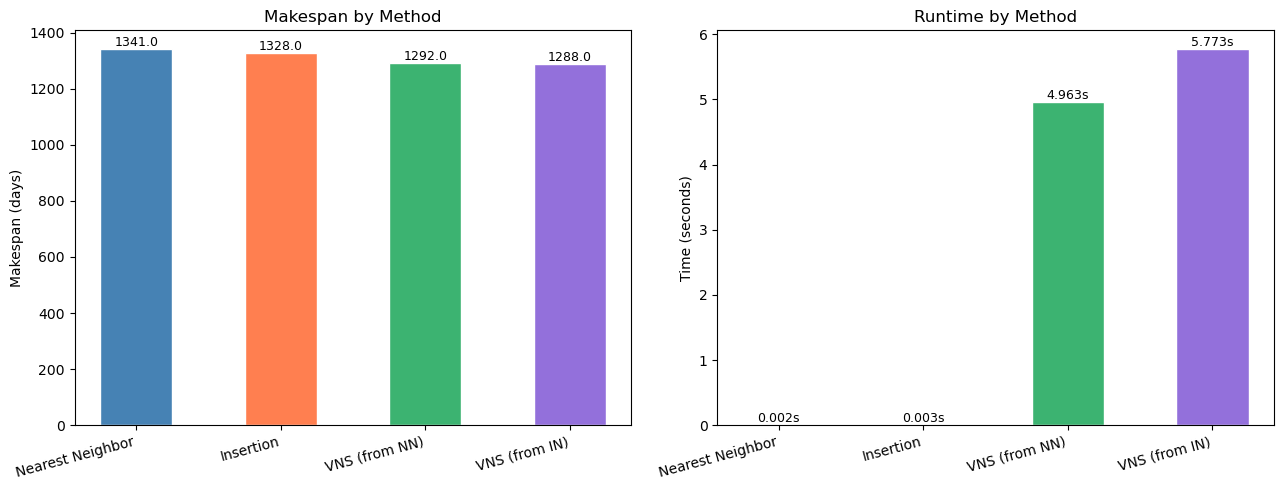

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
methods = results['Method'].tolist()

# Objective values
bars = axes[0].bar(methods, results['Objective'], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Makespan by Method')
axes[0].set_ylabel('Makespan (days)')
axes[0].set_xticklabels(methods, rotation=15, ha='right')
for bar, val in zip(bars, results['Objective']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)


# Runtime
bars2 = axes[1].bar(methods, results['Runtime (s)'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Runtime by Method')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_xticklabels(methods, rotation=15, ha='right')
for bar, val in zip(bars2, results['Runtime (s)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.3f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Improvement Analysis

How much does VNS improve over each heuristic starting point

VNS improvement over NN : 3.65%
VNS improvement over IN : 2.98%


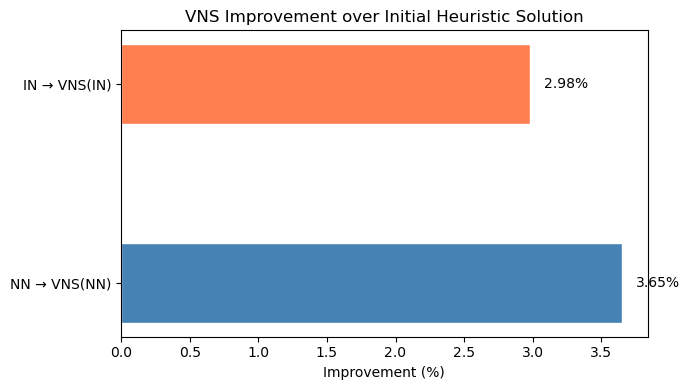

In [23]:
improvement_NN = (solution_NN[1] - solution_VNS_NN[1]) / solution_NN[1] * 100
improvement_IN = (solution_IN[1] - solution_VNS_IN[1]) / solution_NN[1] * 100

print(f"VNS improvement over NN : {improvement_NN:.2f}%")
print(f"VNS improvement over IN : {improvement_IN:.2f}%")

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['NN → VNS(NN)', 'IN → VNS(IN)']
improvements = [improvement_NN, improvement_IN]
bars = ax.barh(labels, improvements, color=['steelblue', 'coral'], edgecolor='white', height=0.4)
ax.set_xlabel('Improvement (%)')
ax.set_title('VNS Improvement over Initial Heuristic Solution')
for bar, val in zip(bars, improvements):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Sensitivity Analysis

We evaluate how the objective value responds to changes in the number of rigs $M$.

In [31]:
rigs_number = list(range(2, 6))

sensitivity = []
for m in rigs_number:
    solution_NN = nearest_neighbor(travel_time, drilling_time, m)
    solution_VNS = variable_neighborhood_search(solution_NN[0], devices_travel_time, well_drilling_time)
    sensitivity.append({
        'M': m,
        'NN': solution_NN[1],
        'VNS': solution_VNS[1]
    })

df_sens = pd.DataFrame(sensitivity).set_index('M')
display(df_sens)

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
27

,NN,VNS
M,,
2,1341.0,1287.0
3,875.0,863.0
4,680.0,651.0
5,558.0,519.0


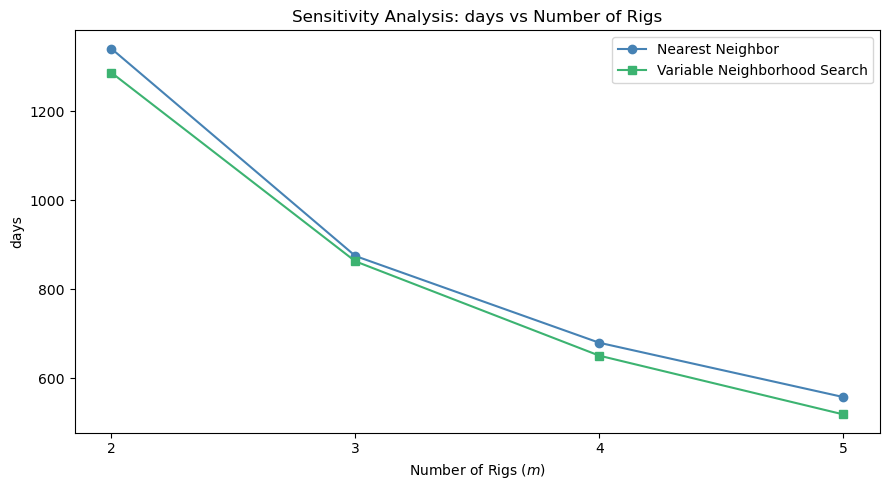

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sens.index, df_sens['NN'],  marker='o', label='Nearest Neighbor', color='steelblue')
ax.plot(df_sens.index, df_sens['VNS'], marker='s', label='Variable Neighborhood Search', color='mediumseagreen')
ax.set_xlabel('Number of Rigs ($m$)')
ax.set_ylabel('days')
ax.set_title('Sensitivity Analysis: days vs Number of Rigs')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

## 10. Results Summary

In [34]:
best_method = results.loc[results['Objective'].idxmin(), 'Method']
best_objective   = results['Objective'].min()

print("=" * 50)
print(" RESULTS SUMMARY")
print("=" * 50)
print(f" Instance : Hassi Bir Rekaiz — {n_wells} wells")
print(f" Best method    : {best_method}")
print(f" Best makespan  : {best_objective:.2f} days")
print(f" VNS gain (NN)  : {improvement_NN:.2f}%")
print(f" VNS gain (IN)  : {improvement_IN:.2f}%")
print("=" * 50)
display(results.set_index('Method'))

 RESULTS SUMMARY
 Instance : Hassi Bir Rekaiz — 25 wells
 Best method    : VNS (from IN)
 Best makespan  : 1288.00 days
 VNS gain (NN)  : 3.65%
 VNS gain (IN)  : 2.98%


,Objective,Runtime (s),Gap vs Best (%)
Method,,,
Nearest Neighbor,1341.0,0.001995,4.11
Insertion,1328.0,0.002614,3.11
VNS (from NN),1292.0,4.962807,0.31
VNS (from IN),1288.0,5.773009,0.00
